# 🍽️ Restaurant Data Analysis using Python

## Project Overview

This project analyzes a restaurant dataset containing information about restaurant names, cuisines, cities, ratings, price ranges, online delivery, and other business-related features.

The objective of this project is to perform Exploratory Data Analysis (EDA) to identify patterns, discover meaningful business insights, and visualize important trends in the restaurant industry.

## Objectives

- Perform data cleaning and preprocessing.
- Analyze the most popular cuisines.
- Study restaurant distribution across cities.
- Analyze price range distribution.
- Compare restaurants with and without online delivery.
- Generate business insights using data visualization.


# 2.Import Libraries

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


# 3.Load Dataset

In [2]:
# Load the dataset
df = pd.read_csv("Dataset.csv")

# Display the first 5 rows
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


# 4.Dataset Overview

In this section, we examine the structure of the dataset, including the number of rows, columns, data types, and missing values. Understanding the dataset before analysis helps identify potential issues and prepares the data for further exploration.

In [3]:
# Shape of the dataset
print("Rows and Columns:", df.shape)

# Column names
print("\nColumn Names:")
print(df.columns.tolist())

Rows and Columns: (9551, 21)

Column Names:
['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']


In [4]:
# Information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

### Observation

- Dataset contains 9,551 records.
- Most columns have no missing values.
- Only the **Cuisines** column contains a few missing values.

In [5]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing.sort_values("Missing Values", ascending=False)

,Missing Values,Percentage
Cuisines,9,0.094231
Restaurant Name,0,0.000000
Country Code,0,0.000000
City,0,0.000000
Restaurant ID,0,0.000000
Address,0,0.000000
Locality,0,0.000000
Longitude,0,0.000000
Locality Verbose,0,0.000000
Latitude,0,0.000000


In [6]:
# Statistical summary
df.describe()


,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


# 5.Data Cleaning

Data cleaning is an important step before performing analysis. In this section, duplicate records are checked, missing values are identified, and necessary preprocessing is performed to improve data quality.

In [7]:
# Check duplicate records
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [8]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

Cuisines                0.094231
Restaurant Name         0.000000
Country Code            0.000000
City                    0.000000
Restaurant ID           0.000000
Address                 0.000000
Locality                0.000000
Longitude               0.000000
Locality Verbose        0.000000
Latitude                0.000000
Average Cost for two    0.000000
Currency                0.000000
Has Table booking       0.000000
Has Online delivery     0.000000
Is delivering now       0.000000
Switch to order menu    0.000000
Price range             0.000000
Aggregate rating        0.000000
Rating color            0.000000
Rating text             0.000000
Votes                   0.000000
dtype: float64

In [9]:
df.drop_duplicates(inplace=True)

print("Dataset Shape:", df.shape)

Dataset Shape: (9551, 21)


In [10]:
df["Cuisines"] = df["Cuisines"].fillna("Unknown")

In [11]:
df.to_csv("Cleaned_Dataset.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


---

## 6.1 Task 1 – Top Cuisines

### Objective

Identify the top three most common cuisines served by restaurants and calculate the percentage of restaurants serving each cuisine.

In [12]:
# Display first 10 cuisine values
df["Cuisines"].head(10)

0            French, Japanese, Desserts
1                              Japanese
2      Seafood, Asian, Filipino, Indian
3                       Japanese, Sushi
4                      Japanese, Korean
5                               Chinese
6                       Asian, European
7    Seafood, Filipino, Asian, European
8               European, Asian, Indian
9                              Filipino
Name: Cuisines, dtype: object

In [13]:
# Split cuisines into individual cuisines
all_cuisines = df["Cuisines"].str.split(",").explode()

# Remove extra spaces
all_cuisines = all_cuisines.str.strip()

# Display first 10 cuisines
all_cuisines.head(10)

0      French
0    Japanese
0    Desserts
1    Japanese
2     Seafood
2       Asian
2    Filipino
2      Indian
3    Japanese
3       Sushi
Name: Cuisines, dtype: object

In [14]:
# Top 3 Most Popular Restaurant Cuisines
top3 = all_cuisines.value_counts().head(3)

print(top3)

Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Name: count, dtype: int64


In [15]:
# Percentage of restaurants serving each cuisine
percentage = (top3 / len(df)) * 100

print(percentage.round(2))

Cuisines
North Indian    41.46
Chinese         28.64
Fast Food       20.79
Name: count, dtype: float64


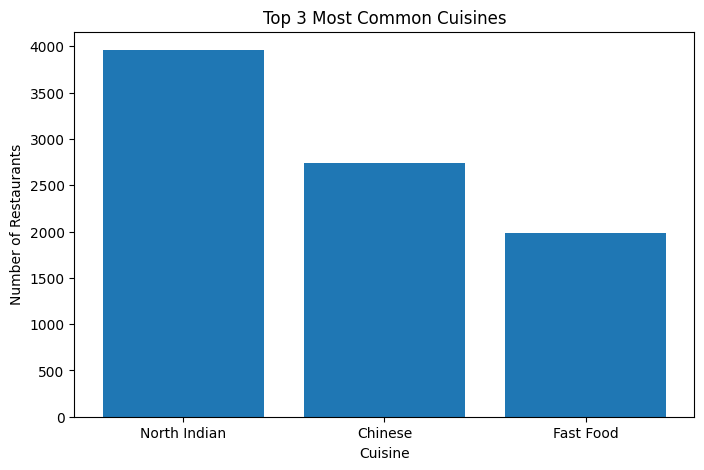

In [16]:
plt.figure(figsize=(8,5))

plt.bar(top3.index, top3.values)

plt.title("Top 3 Most Common Cuisines")
plt.xlabel("Cuisine")
plt.ylabel("Number of Restaurants")

plt.show()

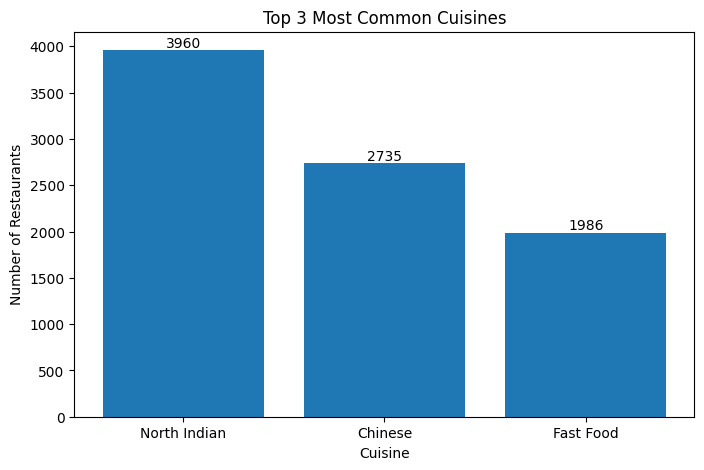

In [17]:
plt.figure(figsize=(8,5))

bars = plt.bar(top3.index, top3.values)

plt.title("Top 3 Most Common Cuisines")
plt.xlabel("Cuisine")
plt.ylabel("Number of Restaurants")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        int(height),
        ha="center",
        va="bottom"
    )
    plt.savefig(
    "images/top_cuisines.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Insights

- North Indian cuisine is the most commonly served cuisine.
- Chinese cuisine is also highly popular among restaurants.
- Fast Food is one of the top choices, indicating high customer demand.
- Restaurants focusing on these cuisines may attract a larger customer base.


### Summary

North Indian cuisine dominates the market, followed by Chinese and Fast Food.

---

## 6.2 Task 2 – City Analysis

### Objective

The objective of this analysis is to:

- Identify the city with the highest number of restaurants.
- Calculate the average restaurant rating for each city.
- Determine the city with the highest average rating.
- Visualize the distribution of restaurants across the top 10 cities.

In [18]:
# Count restaurants by city
city_count = df["City"].value_counts()

# Top 10 Cities with the Highest Number of Restaurants
city_count.head(10)

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Ahmedabad         21
Amritsar          21
Guwahati          21
Name: count, dtype: int64

In [19]:
print("City with Highest Number of Restaurants:")
print(city_count.head(1))

City with Highest Number of Restaurants:
City
New Delhi    5473
Name: count, dtype: int64


In [20]:
average_rating = (
    df.groupby("City")["Aggregate rating"]
      .mean()
      .sort_values(ascending=False)
)

average_rating.head(10)

City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Beechworth          4.600000
London              4.535000
Taguig City         4.525000
Secunderabad        4.500000
Lincoln             4.500000
Name: Aggregate rating, dtype: float64

In [21]:
print("City with Highest Average Rating:")
print(average_rating.head(1))

City with Highest Average Rating:
City
Inner City    4.9
Name: Aggregate rating, dtype: float64


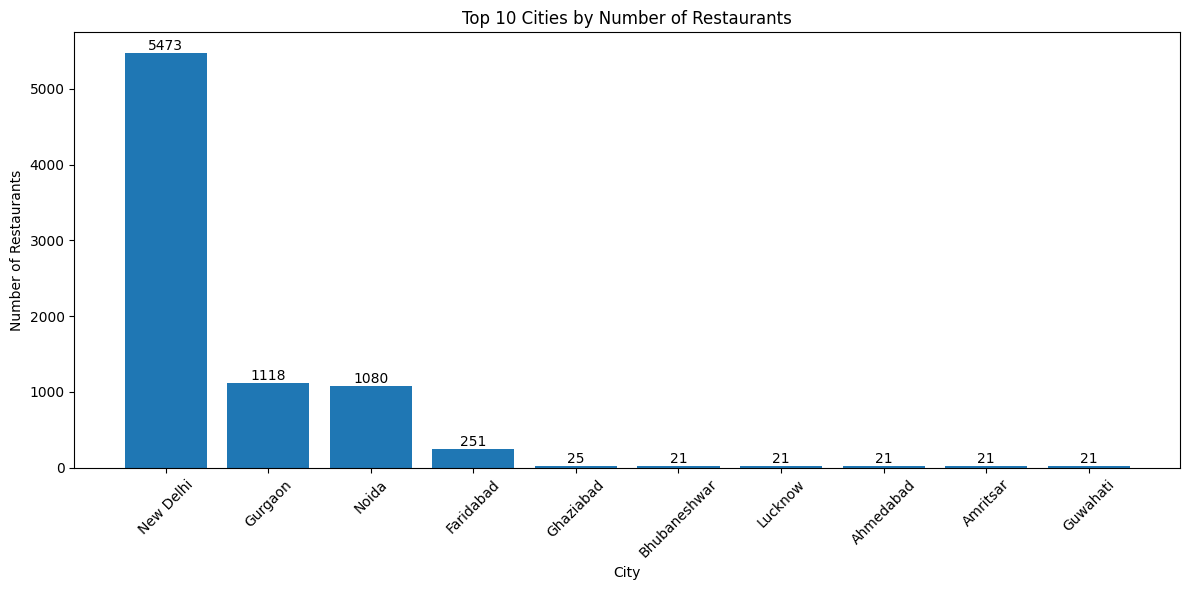

In [22]:
plt.figure(figsize=(12,6))

top10 = city_count.head(10)

bars = plt.bar(top10.index, top10.values)

plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        int(height),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig(
    "images/city_analysis.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Business Insights

- New Delhi has the highest number of restaurants.
- Inner City has the highest average rating.
- Cities with fewer restaurants often have higher average ratings.

### Summary

New Delhi dominates in restaurant count, while Inner City leads in customer satisfaction. This suggests that having more restaurants does not necessarily result in higher ratings.

---

## 6.3 Task 3 – Price Range Distribution

### Objective

The objective of this analysis is to:

- Analyze the distribution of restaurants across different price ranges.
- Calculate the percentage of restaurants in each price category.
- Visualize the price range distribution.
- Identify the most common pricing category among restaurants.

In [23]:
# Display unique price range values
df["Price range"].unique()

array([3, 4, 2, 1])

In [24]:
# Count restaurants in each price range
price_count = df["Price range"].value_counts().sort_index()

print(price_count)

Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64


In [25]:
# Percentage of restaurants in each price range
price_percentage = (
    price_count / len(df)
) * 100

print(price_percentage.round(2))

Price range
1    46.53
2    32.59
3    14.74
4     6.14
Name: count, dtype: float64


In [26]:
price_labels = {
    1: "Low",
    2: "Medium",
    3: "High",
    4: "Luxury"
}

price_count.index = price_count.index.map(price_labels)

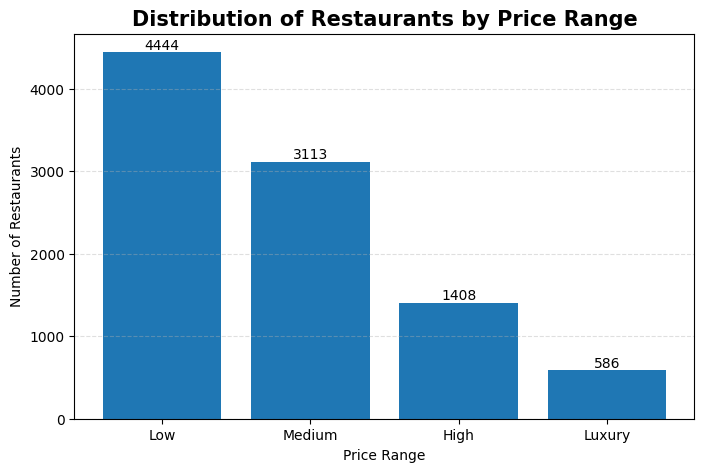

In [27]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    price_count.index.astype(str),
    price_count.values
)

plt.title(
    "Distribution of Restaurants by Price Range",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

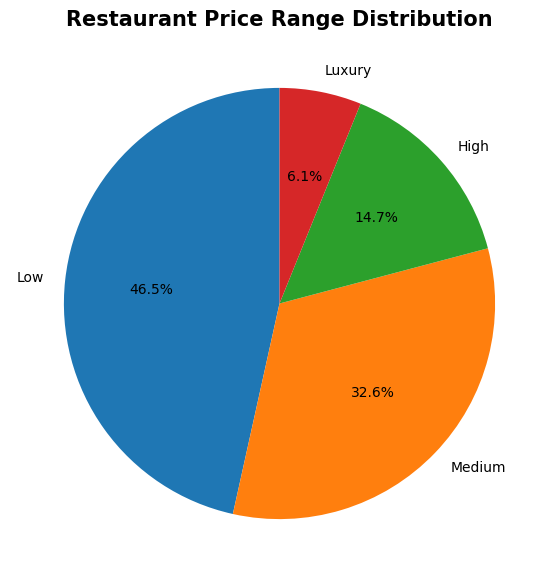

In [28]:
plt.figure(figsize=(7,7))

plt.pie(
    price_count.values,
    labels=price_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Restaurant Price Range Distribution",
    fontsize=15,
    fontweight="bold"
)
plt.savefig(
    "images/price_range_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Business Insights

- Price Range **1** is the most common category, representing **46.53%** of all restaurants.
- Price Range **2** accounts for **32.59%**, making it the second most popular category.
- Only **14.74%** of restaurants fall under Price Range **3**, indicating fewer premium restaurants.
- Price Range **4** represents just **6.14%** of restaurants, showing that luxury restaurants are relatively rare.
- The restaurant market is primarily focused on affordable and mid-priced dining options.

### Summary

The analysis shows that nearly half of the restaurants belong to Price Range 1, while luxury restaurants (Price Range 4) make up only a small portion of the dataset. This indicates that the restaurant industry mainly targets budget-conscious and mid-range customers.

---

## 6.4 Task 4 – Online Delivery Analysis

### Objective

The objective of this analysis is to:

- Determine the percentage of restaurants that offer online delivery.
- Compare the average ratings of restaurants with and without online delivery.
- Visualize the distribution of online delivery services.
- Draw business insights based on the findings.

In [29]:
# Count restaurants offering online delivery
delivery_count = df["Has Online delivery"].value_counts()

print(delivery_count)

Has Online delivery
No     7100
Yes    2451
Name: count, dtype: int64


In [30]:
# Calculate percentage
delivery_percentage = (
    delivery_count / len(df)
) * 100

print(delivery_percentage.round(2))

Has Online delivery
No     74.34
Yes    25.66
Name: count, dtype: float64


In [31]:
average_delivery_rating = (
    df.groupby("Has Online delivery")["Aggregate rating"]
      .mean()
)

print(average_delivery_rating)

Has Online delivery
No     2.465296
Yes    3.248837
Name: Aggregate rating, dtype: float64


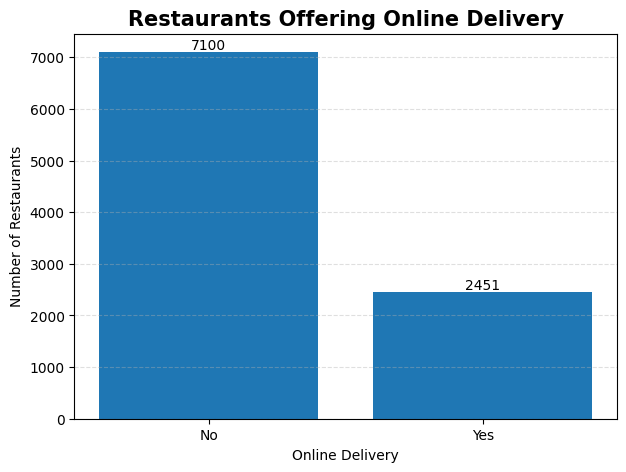

In [32]:
plt.figure(figsize=(7,5))

bars = plt.bar(
    delivery_count.index,
    delivery_count.values
)

plt.title(
    "Restaurants Offering Online Delivery",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Online Delivery")
plt.ylabel("Number of Restaurants")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha='center',
        va='bottom'
    )

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

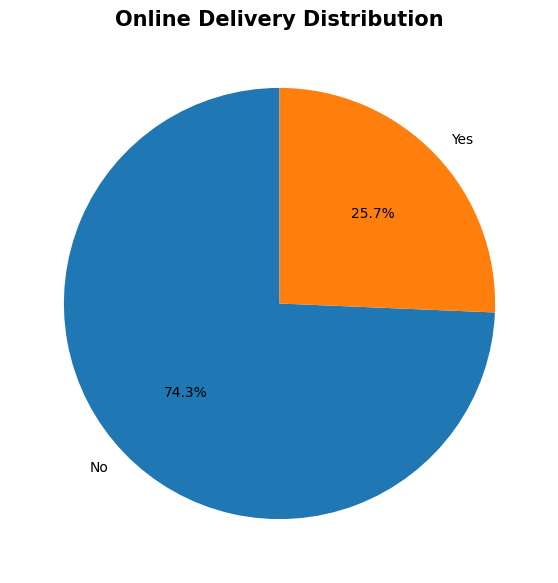

In [33]:
plt.figure(figsize=(7,7))

plt.pie(
    delivery_count.values,
    labels=delivery_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Online Delivery Distribution",
    fontsize=15,
    fontweight="bold"
)
plt.savefig(
    "images/online_delivery_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

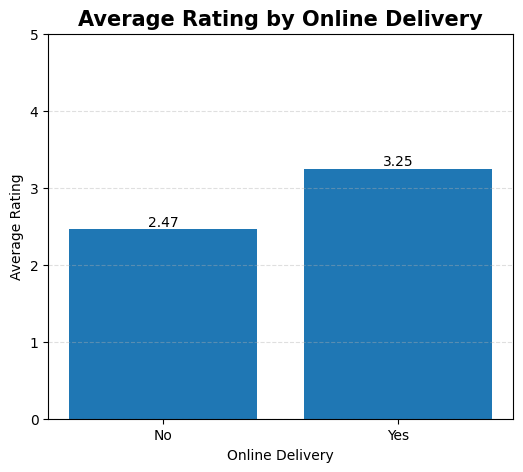

In [34]:
plt.figure(figsize=(6,5))

bars = plt.bar(
    average_delivery_rating.index,
    average_delivery_rating.values
)

plt.title(
    "Average Rating by Online Delivery",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Online Delivery")
plt.ylabel("Average Rating")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        round(bar.get_height(),2),
        ha='center',
        va='bottom'
    )

plt.ylim(0,5)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

### Business Insights

- Out of 9,551 restaurants, only **2,451 (25.66%)** offer online delivery, while **7,100 (74.34%)** do not.
- Restaurants offering online delivery have an **average rating of 3.25**, which is significantly higher than restaurants without online delivery (**2.47**).
- Online delivery services appear to be associated with better customer ratings, possibly due to increased convenience and customer satisfaction.
- Most restaurants still operate without online delivery, indicating opportunities for businesses to expand their digital services.

### Summary

The analysis reveals that only about one-fourth of restaurants provide online delivery. However, these restaurants receive noticeably higher average ratings than those without online delivery, suggesting that online delivery may positively influence customer satisfaction and restaurant popularity.

# Level 1 Conclusion

The Level 1 analysis focused on understanding the restaurant dataset through exploratory data analysis.

### Key Findings

- North Indian is the most popular cuisine, followed by Chinese and Fast Food.
- New Delhi has the highest number of restaurants, while Inner City has the highest average rating.
- Nearly half of all restaurants fall under the lowest price range, indicating a strong focus on affordable dining.
- Only 25.66% of restaurants offer online delivery, but these restaurants have higher average customer ratings.

Overall, the analysis provides valuable insights into customer preferences, restaurant distribution, pricing strategies, and online delivery adoption.

---

## 7.1 Task 1 – Restaurant Ratings

### Objective

The objective of this analysis is to:

- Analyze the distribution of aggregate restaurant ratings.
- Identify the most common rating range.
- Calculate the average number of votes received by restaurants.
- Visualize rating distribution and voting patterns.

In [35]:
# Display unique ratings
df["Aggregate rating"].unique()

array([4.8, 4.5, 4.4, 4.9, 4. , 4.2, 4.3, 3.6, 4.7, 3. , 3.8, 3.7, 3.2,
       3.1, 0. , 4.1, 3.3, 4.6, 3.9, 3.4, 3.5, 2.2, 2.9, 2.4, 2.6, 2.8,
       2.1, 2.7, 2.5, 1.8, 2. , 2.3, 1.9])

In [36]:
# Summary statistics for ratings
df["Aggregate rating"].describe()

count    9551.000000
mean        2.666370
std         1.516378
min         0.000000
25%         2.500000
50%         3.200000
75%         3.700000
max         4.900000
Name: Aggregate rating, dtype: float64

### Observation

- The dataset contains **9,551** restaurant records.
- The average aggregate rating is **2.67**.
- Ratings range from **0.0** to **4.9**.
- The presence of many **0.0 ratings** suggests that a considerable number of restaurants have not yet been reviewed.

In [37]:
rating_count = (
    df["Aggregate rating"]
    .value_counts()
    .sort_index()
)

rating_count

Aggregate rating
0.0    2148
1.8       1
1.9       2
2.0       7
2.1      15
2.2      27
2.3      47
2.4      87
2.5     110
2.6     191
2.7     250
2.8     315
2.9     381
3.0     468
3.1     519
3.2     522
3.3     483
3.4     498
3.5     480
3.6     458
3.7     427
3.8     400
3.9     335
4.0     266
4.1     274
4.2     221
4.3     174
4.4     144
4.5      95
4.6      78
4.7      42
4.8      25
4.9      61
Name: count, dtype: int64

In [38]:
rating_table = pd.DataFrame({
    "Rating": rating_count.index,
    "Number of Restaurants": rating_count.values
})

rating_table

,Rating,Number of Restaurants
0,0.0,2148
1,1.8,1
2,1.9,2
3,2.0,7
4,2.1,15
5,2.2,27
6,2.3,47
7,2.4,87
8,2.5,110
9,2.6,191


In [39]:
average_votes = df["Votes"].mean()

print(f"Average Votes: {average_votes:.2f}")

Average Votes: 156.91


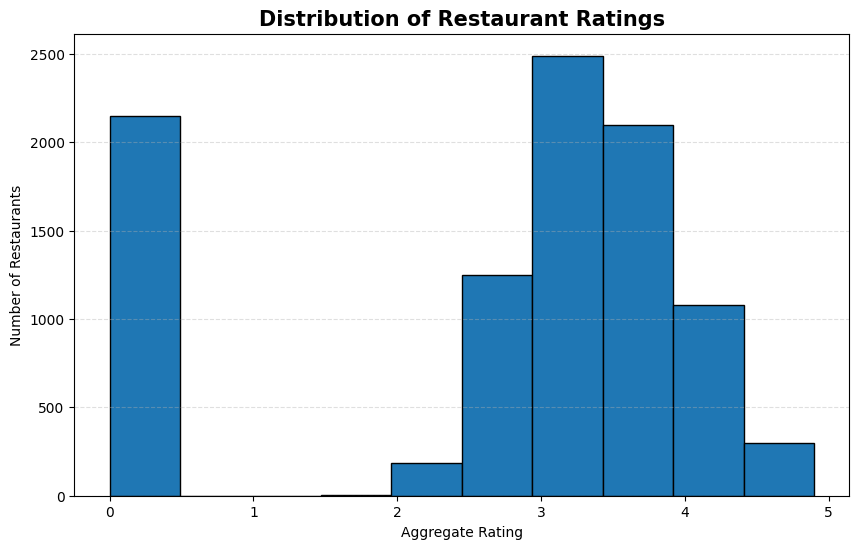

In [40]:
plt.figure(figsize=(10,6))

plt.hist(
    df["Aggregate rating"],
    bins=10,
    edgecolor="black"
)

plt.title(
    "Distribution of Restaurant Ratings",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Aggregate Rating")
plt.ylabel("Number of Restaurants")

plt.grid(axis="y", linestyle="--", alpha=0.4)


plt.show()

In [41]:
rating_bins = [0, 2, 3, 4, 5]

rating_labels = [
    "Poor (0-2)",
    "Average (2-3)",
    "Good (3-4)",
    "Excellent (4-5)"
]

df["Rating Category"] = pd.cut(
    df["Aggregate rating"],
    bins=rating_bins,
    labels=rating_labels,
    include_lowest=True
)

rating_category = df["Rating Category"].value_counts().sort_index()

print(rating_category)

Rating Category
Poor (0-2)         2158
Average (2-3)      1891
Good (3-4)         4388
Excellent (4-5)    1114
Name: count, dtype: int64


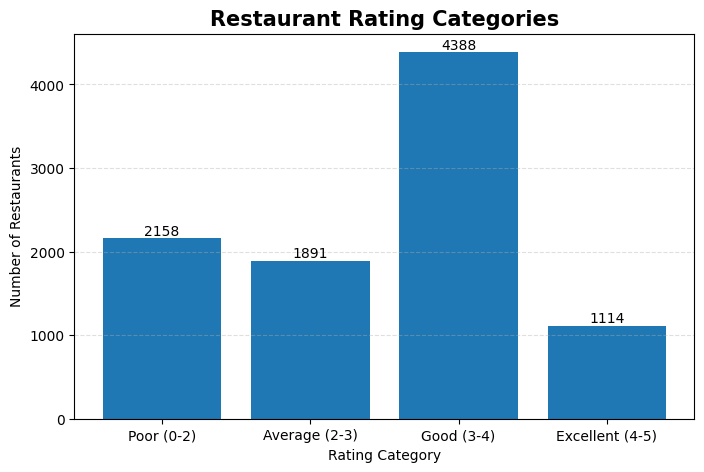

In [42]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    rating_category.index.astype(str),
    rating_category.values
)

plt.title(
    "Restaurant Rating Categories",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Rating Category")
plt.ylabel("Number of Restaurants")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

### Business Insights

- The average restaurant rating in the dataset is **2.67**.
- The average number of votes received by restaurants is **156.91**.
- Most restaurants fall into the **Good (3–4)** rating category, with **4,388 restaurants**, indicating that the majority of restaurants receive satisfactory customer ratings.
- A significant number of restaurants have an **Aggregate Rating of 0.0**, which generally indicates that they have not yet been rated by customers.
- Restaurants with ratings between **4 and 5** are comparatively fewer, suggesting that excellent-rated restaurants are less common.

### Summary

The rating analysis shows that most restaurants are rated between **3 and 4**, indicating generally positive customer experiences. However, many restaurants have no ratings, which affects the overall distribution. On average, restaurants receive **156.91 votes**, reflecting a moderate level of customer engagement.

---

## 7.2 Task 2 – Cuisine Combination

### Objective

The objective of this analysis is to:

- Identify the most common cuisine combinations offered by restaurants.
- Analyze the average ratings of different cuisine combinations.
- Determine whether certain cuisine combinations receive higher customer ratings.
- Visualize the most popular cuisine combinations.

In [43]:
# Display first 10 cuisine combinations
df["Cuisines"].head(10)

0            French, Japanese, Desserts
1                              Japanese
2      Seafood, Asian, Filipino, Indian
3                       Japanese, Sushi
4                      Japanese, Korean
5                               Chinese
6                       Asian, European
7    Seafood, Filipino, Asian, European
8               European, Asian, Indian
9                              Filipino
Name: Cuisines, dtype: object

In [44]:
# Count cuisine combinations
cuisine_combination = (
    df["Cuisines"]
    .value_counts()
    .head(10)
)

print(cuisine_combination)

Cuisines
North Indian                      936
North Indian, Chinese             511
Fast Food                         354
Chinese                           354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64


In [45]:
cuisine_table = pd.DataFrame({
    "Cuisine Combination": cuisine_combination.index,
    "Number of Restaurants": cuisine_combination.values
})

cuisine_table

,Cuisine Combination,Number of Restaurants
0,North Indian,936
1,"North Indian, Chinese",511
2,Fast Food,354
3,Chinese,354
4,"North Indian, Mughlai",334
5,Cafe,299
6,Bakery,218
7,"North Indian, Mughlai, Chinese",197
8,"Bakery, Desserts",170
9,Street Food,149


In [46]:
average_combination_rating = (
    df.groupby("Cuisines")["Aggregate rating"]
      .mean()
      .sort_values(ascending=False)
)

average_combination_rating.head(10)

Cuisines
Italian, Deli                      4.9
American, Coffee and Tea           4.9
American, BBQ, Sandwich            4.9
BBQ, Breakfast, Southern           4.9
Italian, Bakery, Continental       4.9
American, Burger, Grill            4.9
Hawaiian, Seafood                  4.9
Mexican, American, Healthy Food    4.9
American, Caribbean, Seafood       4.9
Mughlai, Lucknowi                  4.9
Name: Aggregate rating, dtype: float64

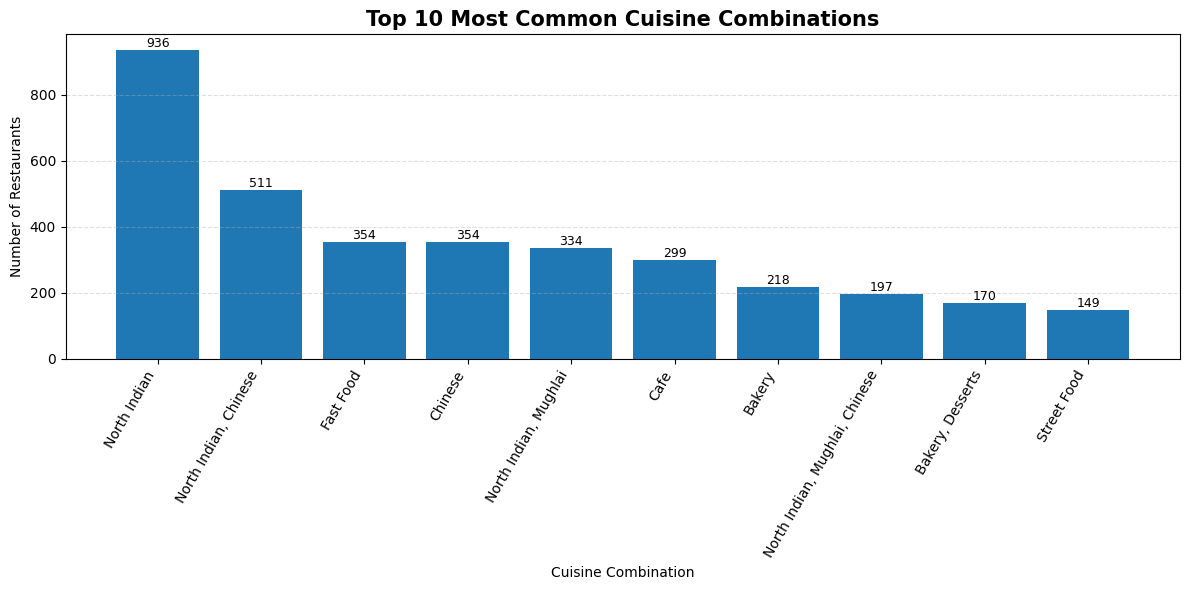

In [47]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    cuisine_combination.index,
    cuisine_combination.values
)

plt.title(
    "Top 10 Most Common Cuisine Combinations",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Cuisine Combination")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=60, ha="right")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

In [51]:
plt.figure(figsize=(8,6))

plt.scatter(
    top_rated["Restaurant Count"],
    top_rated["Aggregate rating"]
)

plt.title("Restaurant Count vs Average Rating")
plt.xlabel("Number of Restaurants")
plt.ylabel("Average Rating")

plt.grid(True)

plt.show()

NameError: name 'top_rated' is not defined

<Figure size 800x600 with 0 Axes>

In [ ]:
top_rated = (
    df.groupby("Cuisines")
      .agg({
          "Aggregate rating":"mean",
          "Restaurant ID":"count"
      })
      .rename(columns={"Restaurant ID":"Restaurant Count"})
)

# Keep only combinations appearing in at least 5 restaurants
top_rated = top_rated[top_rated["Restaurant Count"] >= 5]

top_rated = top_rated.sort_values(
    by="Aggregate rating",
    ascending=False
)

top_rated.head(10)

,Aggregate rating,Restaurant Count
Cuisines,,
"North Indian, European, Mediterranean",4.460000,5
Burger,4.450000,6
Modern Indian,4.345455,11
Indian,4.250000,18
International,4.233333,6
"Italian, Pizza, Sandwich",4.220000,5
French,4.185714,7
Steak,4.185714,7
"Cafe, Bakery, Desserts",4.166667,6


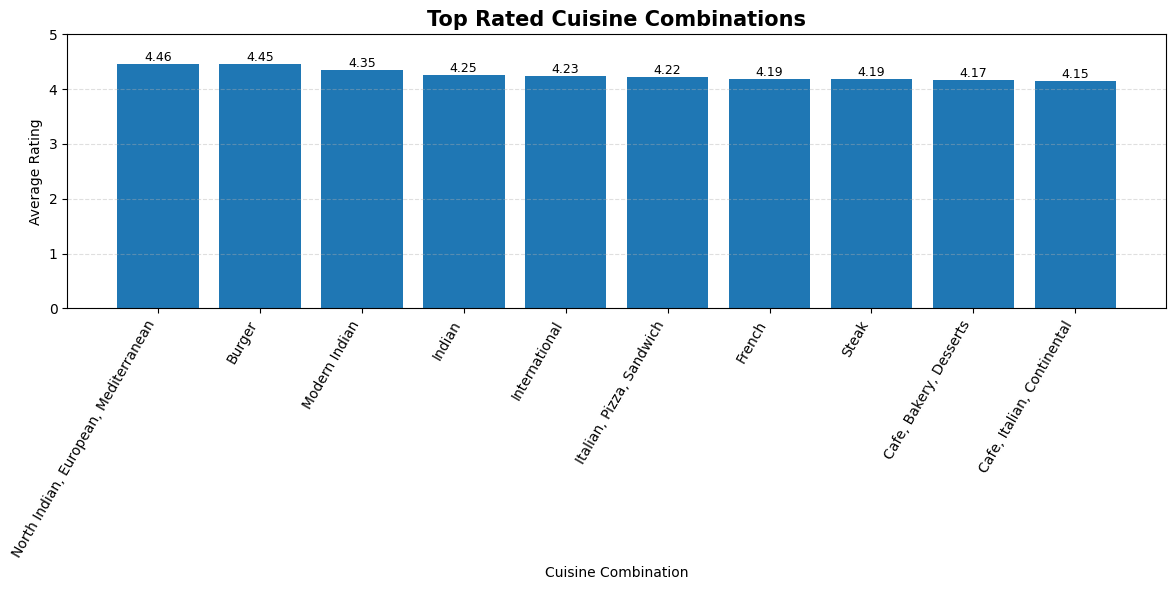

In [ ]:
top10 = top_rated.head(10)

plt.figure(figsize=(12,6))

bars = plt.bar(
    top10.index,
    top10["Aggregate rating"]
)

plt.title(
    "Top Rated Cuisine Combinations",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Cuisine Combination")
plt.ylabel("Average Rating")

plt.xticks(rotation=60, ha="right")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        round(bar.get_height(),2),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.ylim(0,5)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

### Business Insights

- **North Indian** is the most common cuisine combination, with **936 restaurants**, making it the dominant cuisine in the dataset.
- **North Indian, Chinese** is the second most common combination, followed by **Fast Food** and **Chinese** cuisines.
- Cuisine combinations such as **North Indian, European, Mediterranean**, **Burger**, and **Modern Indian** receive the highest average ratings among combinations that appear in at least five restaurants.
- Highly rated cuisine combinations are not always the most common, suggesting that popularity does not necessarily indicate higher customer satisfaction.

### Observation

- North Indian cuisine appears most frequently in the dataset.
- Multi-cuisine restaurants are very common.
- Several cuisine combinations achieve ratings above **4.2**, demonstrating consistently high customer satisfaction.

---

## 7.3 Task 3 – Geographic Analysis

### Objective

The objective of this analysis is to:

- Visualize restaurant locations using latitude and longitude.
- Identify geographic patterns and clusters.
- Analyze how restaurants are distributed across different regions.

In [ ]:
df[["Latitude", "Longitude"]].head()  

,Latitude,Longitude
0,14.565443,121.027535
1,14.553708,121.014101
2,14.581404,121.056831
3,14.585318,121.056475
4,14.584450,121.057508


In [ ]:
df[["Latitude", "Longitude"]].isnull().sum()

Latitude     0
Longitude    0
dtype: int64

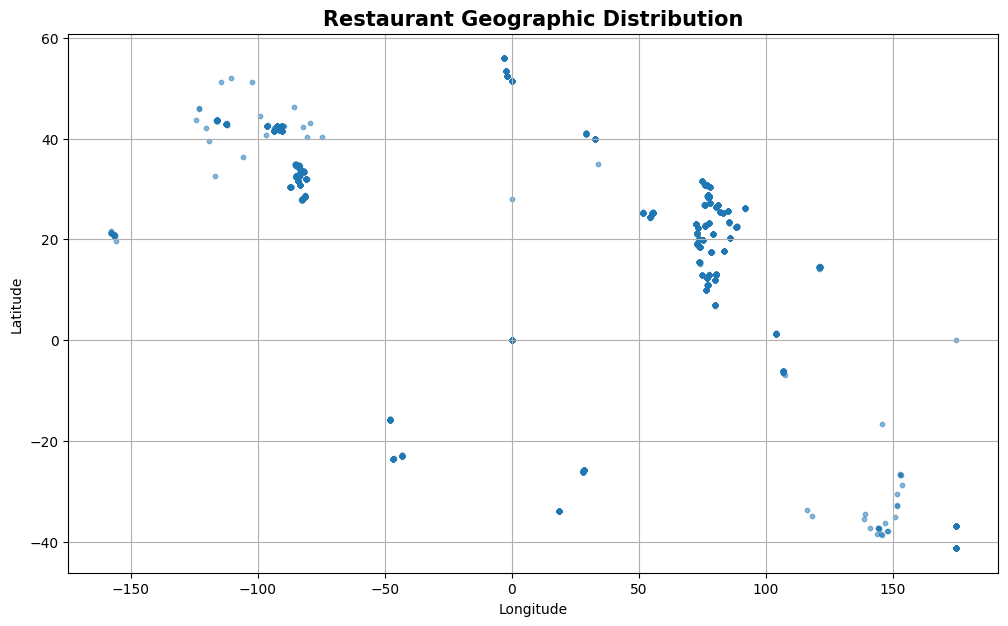

In [ ]:
plt.figure(figsize=(12,7))

plt.scatter(
    df["Longitude"],
    df["Latitude"],
    alpha=0.5,
    s=10
)

plt.title(
    "Restaurant Geographic Distribution",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.grid(True)

plt.show()

In [ ]:
country_mapping = {
    1: "India",
    14: "Australia",
    30: "Brazil",
    37: "Canada",
    94: "Indonesia",
    148: "New Zealand",
    162: "Philippines",
    166: "Qatar",
    184: "Singapore",
    189: "South Africa",
    191: "Sri Lanka",
    208: "Turkey",
    214: "UAE",
    215: "United Kingdom",
    216: "United States"
}

df["Country"] = df["Country Code"].map(country_mapping)

In [ ]:
df[["Country Code", "Country"]].head(10)

,Country Code,Country
0,162,Philippines
1,162,Philippines
2,162,Philippines
3,162,Philippines
4,162,Philippines
5,162,Philippines
6,162,Philippines
7,162,Philippines
8,162,Philippines
9,162,Philippines


In [ ]:
country = df["Country"].value_counts()

print(country)

Country
India             8652
United States      434
United Kingdom      80
Brazil              60
South Africa        60
UAE                 60
New Zealand         40
Turkey              34
Australia           24
Philippines         22
Indonesia           21
Qatar               20
Singapore           20
Sri Lanka           20
Canada               4
Name: count, dtype: int64


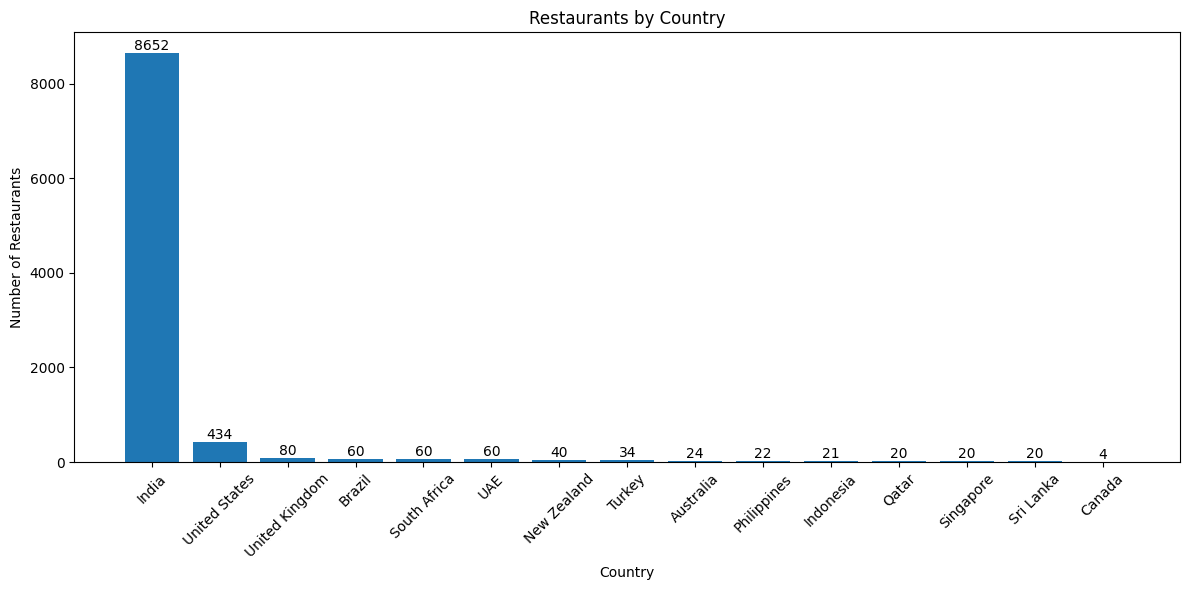

In [ ]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    country.index,
    country.values
)

plt.title("Restaurants by Country")
plt.xlabel("Country")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=45)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Business Insights

- India dominates the dataset with **8,652 restaurants**, representing the vast majority of restaurants analyzed.
- The United States is the second-largest contributor with **434 restaurants**.
- The United Kingdom ranks third with **80 restaurants**.
- Restaurant locations are distributed across multiple countries, showing a global presence of the dataset.
- The geographic scatter plot reveals clear clusters of restaurants, indicating concentration in specific regions rather than uniform distribution.

### Observation

- No missing values were found in the Latitude and Longitude columns.
- Restaurant locations are concentrated in a few geographic regions.
- India contributes significantly more restaurant records than any other country.
- Several countries have relatively small representation, with fewer than 50 restaurants each.

### Summary

The geographic analysis shows that restaurant data is heavily concentrated in India, with smaller contributions from countries such as the United States, United Kingdom, Brazil, and UAE. The scatter plot demonstrates geographic clustering, indicating that restaurants tend to be concentrated in specific urban and commercial regions.

## 7.4 Task 4 – Restaurant Chains

### Objective

The objective of this analysis is to:

- Identify restaurant chains operating in multiple locations.
- Determine the most common restaurant chains.
- Analyze the average ratings of popular restaurant chains.
- Compare popularity and customer satisfaction among chains.

In [ ]:
# Count restaurant names
chain_count = df["Restaurant Name"].value_counts()

chain_count.head(20)

Restaurant Name
Cafe Coffee Day        83
Domino's Pizza         79
Subway                 63
Green Chick Chop       51
McDonald's             48
Keventers              34
Pizza Hut              30
Giani                  29
Baskin Robbins         28
Barbeque Nation        26
Dunkin' Donuts         22
Barista                22
Giani's                22
Pind Balluchi          20
Costa Coffee           20
Wah Ji Wah             19
Pizza Hut Delivery     19
Sagar Ratna            19
Twenty Four Seven      19
Republic of Chicken    18
Name: count, dtype: int64

In [ ]:
# Restaurant chains
chains = chain_count[chain_count > 1]

print("Number of Restaurant Chains:", len(chains))

chains.head(10)

Number of Restaurant Chains: 734


Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64

In [ ]:
top_chains = chains.head(10)

top_chains

Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64

In [ ]:
chain_table = pd.DataFrame({
    "Restaurant Chain": top_chains.index,
    "Number of Outlets": top_chains.values
})

chain_table

,Restaurant Chain,Number of Outlets
0,Cafe Coffee Day,83
1,Domino's Pizza,79
2,Subway,63
3,Green Chick Chop,51
4,McDonald's,48
5,Keventers,34
6,Pizza Hut,30
7,Giani,29
8,Baskin Robbins,28
9,Barbeque Nation,26


In [ ]:
chain_rating = (
    df.groupby("Restaurant Name")["Aggregate rating"]
      .mean()
)

top_chain_rating = chain_rating.loc[top_chains.index]

top_chain_rating.sort_values(ascending=False)

Restaurant Name
Barbeque Nation     4.353846
McDonald's          3.339583
Pizza Hut           3.320000
Subway              2.907937
Keventers           2.870588
Domino's Pizza      2.740506
Giani               2.689655
Green Chick Chop    2.672549
Cafe Coffee Day     2.419277
Baskin Robbins      1.860714
Name: Aggregate rating, dtype: float64

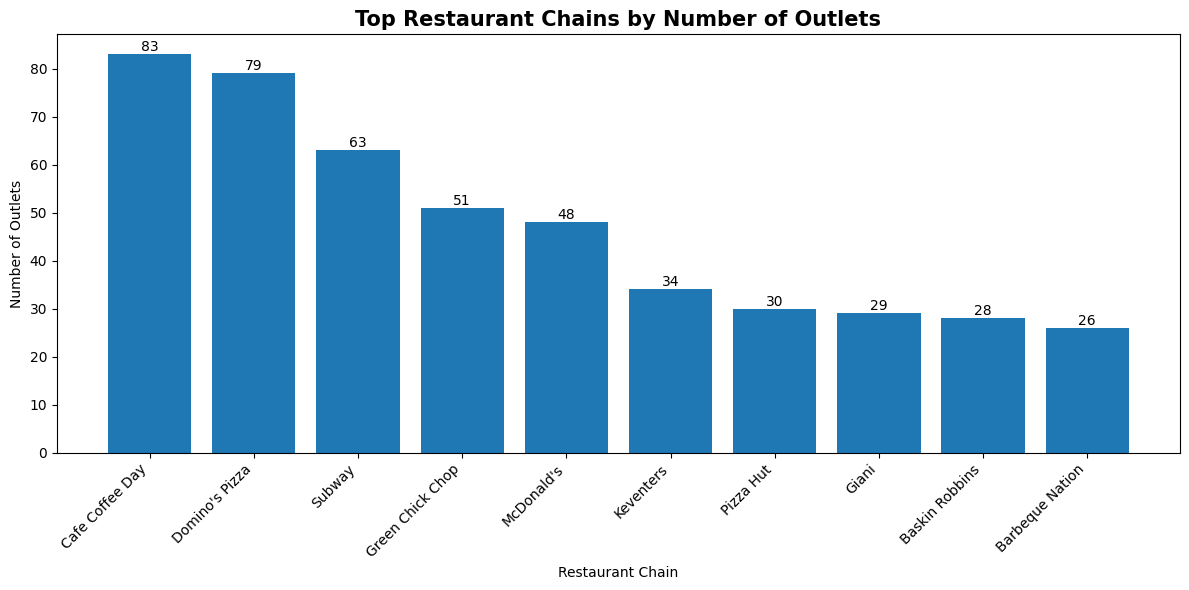

In [ ]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    top_chains.index,
    top_chains.values
)

plt.title(
    "Top Restaurant Chains by Number of Outlets",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Restaurant Chain")
plt.ylabel("Number of Outlets")

plt.xticks(rotation=45, ha="right")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.show()

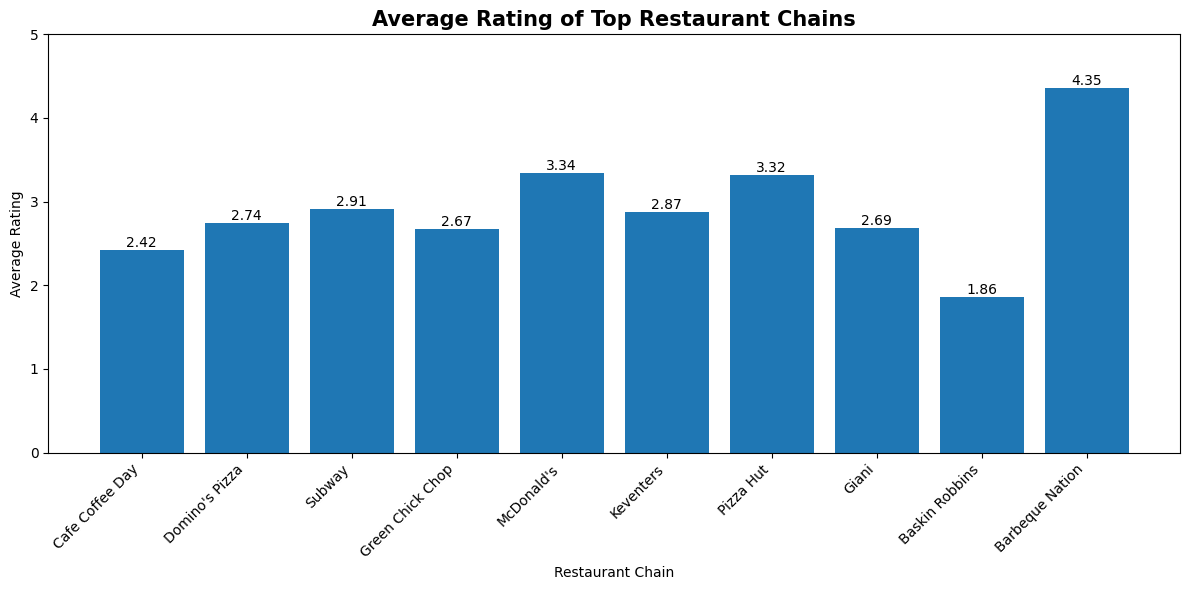

In [ ]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    top_chain_rating.index,
    top_chain_rating.values
)

plt.title(
    "Average Rating of Top Restaurant Chains",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Restaurant Chain")
plt.ylabel("Average Rating")

plt.xticks(rotation=45, ha="right")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        round(bar.get_height(),2),
        ha="center",
        va="bottom"
    )

plt.ylim(0,5)

plt.tight_layout()
plt.savefig(
    "images/restaurant_chains.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Business Insights

- A total of **734 restaurant chains** operate in multiple locations.
- **Cafe Coffee Day** is the largest chain in the dataset with **83 outlets**, followed by **Domino's Pizza (79 outlets)** and **Subway (63 outlets)**.
- **Barbeque Nation** has the highest average rating (**4.35**) among the top restaurant chains.
- Despite having fewer outlets than Cafe Coffee Day and Domino's Pizza, Barbeque Nation receives significantly better customer ratings.
- Popularity (number of outlets) does not necessarily guarantee higher customer satisfaction.

### Observation

- Large restaurant chains dominate the market in terms of outlet count.
- Several chains maintain ratings above 3.0, indicating generally positive customer experiences.
- Some highly popular chains have moderate ratings, suggesting opportunities for service improvement.
- Barbeque Nation stands out as both a recognized chain and a highly rated brand.

# Level 2 Conclusion

Level 2 focused on advanced restaurant analysis, including ratings, cuisine combinations, geographic distribution, and restaurant chains.

### Key Findings

- Most restaurants fall into the **Good (3–4)** rating category.
- The average restaurant rating is **2.67**, with an average of **156.91 votes** per restaurant.
- North Indian cuisine is the most common cuisine combination.
- Several specialized cuisine combinations achieve ratings above **4.2**, indicating high customer satisfaction.
- India contributes the majority of restaurant records in the dataset.
- Cafe Coffee Day is the largest restaurant chain, while Barbeque Nation has the highest average rating among major chains.

Overall, Level 2 provided deeper insights into customer preferences, restaurant performance, geographic distribution, and chain popularity.

## 8.1 Task 1 – Votes Analysis

### Objective

The objective of this analysis is to:

- Analyze the distribution of restaurant votes.
- Identify restaurants with the highest number of votes.
- Examine the relationship between votes and ratings.
- Determine whether highly voted restaurants tend to receive higher ratings.

In [ ]:
# Summary statistics
df["Votes"].describe()

count     9551.000000
mean       156.909748
std        430.169145
min          0.000000
25%          5.000000
50%         31.000000
75%        131.000000
max      10934.000000
Name: Votes, dtype: float64

In [ ]:
top_votes = (
    df[["Restaurant Name", "Votes", "Aggregate rating"]]
    .sort_values(by="Votes", ascending=False)
)

top_votes.head(10)

,Restaurant Name,Votes,Aggregate rating
728,Toit,10934,4.8
735,Truffles,9667,4.7
3994,Hauz Khas Social,7931,4.3
2412,Peter Cat,7574,4.3
739,AB's - Absolute Barbecues,6907,4.6
2414,Barbeque Nation,5966,4.9
743,Big Brewsky,5705,4.5
2307,AB's - Absolute Barbecues,5434,4.9
736,The Black Pearl,5385,4.1
2411,BarBQ,5288,4.2


In [ ]:
top10_votes = top_votes.head(10)

top10_votes

,Restaurant Name,Votes,Aggregate rating
728,Toit,10934,4.8
735,Truffles,9667,4.7
3994,Hauz Khas Social,7931,4.3
2412,Peter Cat,7574,4.3
739,AB's - Absolute Barbecues,6907,4.6
2414,Barbeque Nation,5966,4.9
743,Big Brewsky,5705,4.5
2307,AB's - Absolute Barbecues,5434,4.9
736,The Black Pearl,5385,4.1
2411,BarBQ,5288,4.2


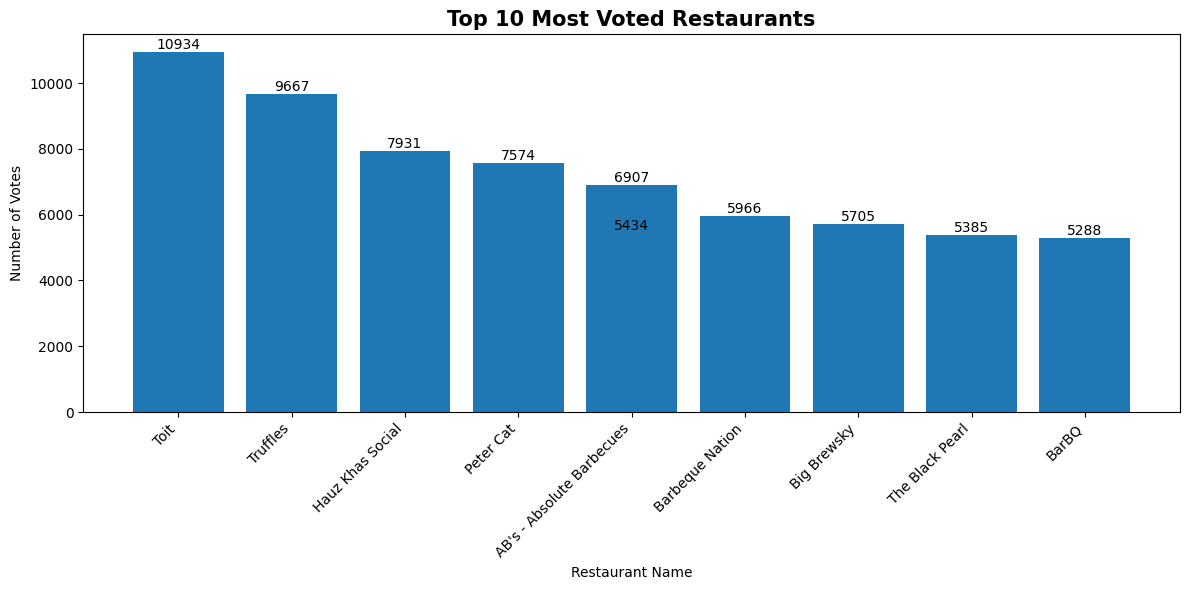

In [ ]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    top10_votes["Restaurant Name"],
    top10_votes["Votes"]
)

plt.title(
    "Top 10 Most Voted Restaurants",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Restaurant Name")
plt.ylabel("Number of Votes")

plt.xticks(rotation=45, ha="right")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.show()

In [ ]:
correlation = df["Votes"].corr(
    df["Aggregate rating"]
)

print(
    f"Correlation between Votes and Ratings: {correlation:.3f}"
)

Correlation between Votes and Ratings: 0.314


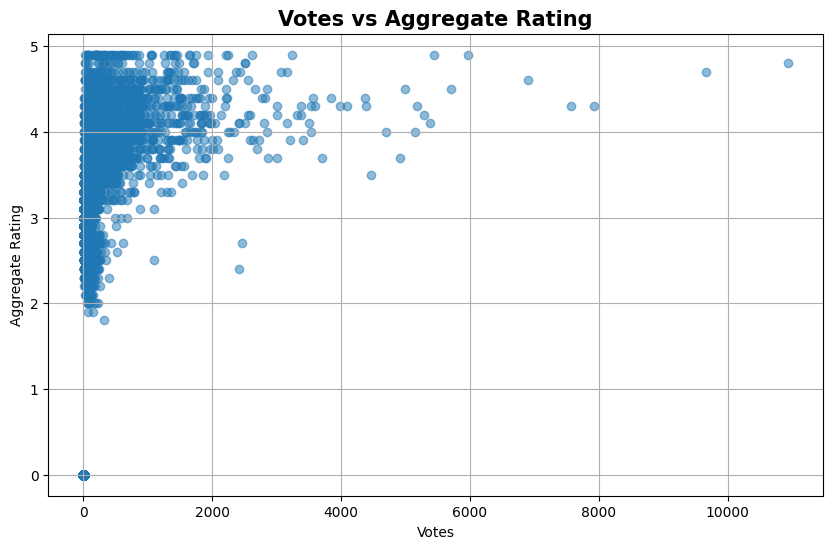

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Votes"],
    df["Aggregate rating"],
    alpha=0.5
)

plt.title(
    "Votes vs Aggregate Rating",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Votes")
plt.ylabel("Aggregate Rating")

plt.grid(True)
plt.savefig(
    "images/votes_vs_ratings.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
rating_bins = [0, 2, 3, 4, 5]

rating_labels = [
    "Poor (0-2)",
    "Average (2-3)",
    "Good (3-4)",
    "Excellent (4-5)"
]

df["Rating Category"] = pd.cut(
    df["Aggregate rating"],
    bins=rating_bins,
    labels=rating_labels,
    include_lowest=True
)

print(df["Rating Category"].head())

0    Excellent (4-5)
1    Excellent (4-5)
2    Excellent (4-5)
3    Excellent (4-5)
4    Excellent (4-5)
Name: Rating Category, dtype: category
Categories (4, object): ['Poor (0-2)' < 'Average (2-3)' < 'Good (3-4)' < 'Excellent (4-5)']


In [ ]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Country', 'Rating Category'],
      dtype='object')

In [ ]:
votes_by_rating = (
    df.groupby("Rating Category")["Votes"]
      .mean()
)

votes_by_rating

C:\Users\anily\AppData\Local\Temp\ipykernel_14568\4067231036.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Rating Category")["Votes"]


Rating Category
Poor (0-2)           1.534291
Average (2-3)       38.991010
Good (3-4)         162.152005
Excellent (4-5)    637.413824
Name: Votes, dtype: float64

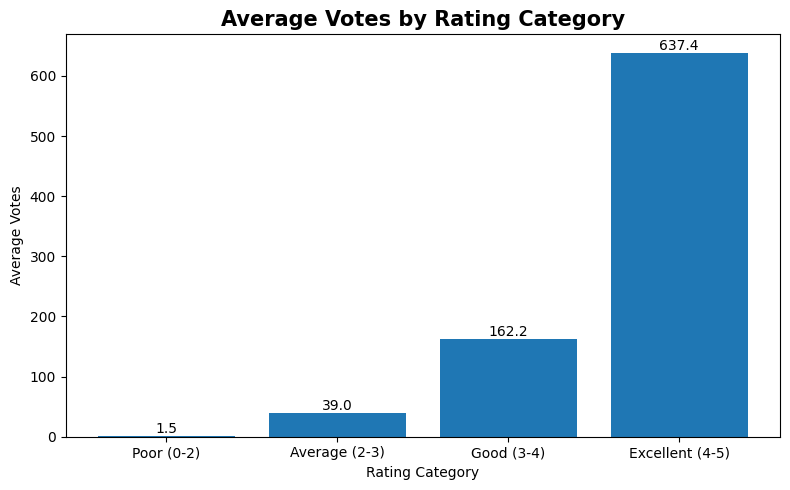

In [ ]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    votes_by_rating.index.astype(str),
    votes_by_rating.values
)

plt.title(
    "Average Votes by Rating Category",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Rating Category")
plt.ylabel("Average Votes")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        round(bar.get_height(),1),
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.show()

### Business Insights

- Restaurants with higher ratings tend to receive more customer votes.
- Excellent-rated restaurants (4–5 stars) receive the highest average votes (~637 votes).
- Poor-rated restaurants receive very few votes on average (~2 votes).
- The correlation between votes and ratings is positive (0.314), indicating that popular restaurants generally have better ratings.
- Restaurants such as Toit, Truffles, and Hauz Khas Social are among the most voted establishments in the dataset.

### Summary

Customer engagement increases significantly with restaurant ratings. Restaurants with excellent ratings attract substantially more votes, suggesting a positive relationship between customer satisfaction and popularity.

### Objective

- Identify cuisines with the highest average ratings.
- Compare customer satisfaction across cuisines.
- Discover which cuisines perform best in terms of ratings.

In [ ]:
# Split cuisines into individual cuisines
cuisine_rating = df.copy()

cuisine_rating["Cuisines"] = cuisine_rating["Cuisines"].fillna("Unknown")

cuisine_rating = cuisine_rating.assign(
    Cuisine=cuisine_rating["Cuisines"].str.split(",")
)

cuisine_rating = cuisine_rating.explode("Cuisine")

cuisine_rating["Cuisine"] = cuisine_rating["Cuisine"].str.strip()

In [ ]:
cuisine_stats = (
    cuisine_rating.groupby("Cuisine")
    .agg({
        "Aggregate rating":"mean",
        "Restaurant ID":"count"
    })
    .rename(columns={"Restaurant ID":"Restaurant Count"})
)

cuisine_stats = cuisine_stats[
    cuisine_stats["Restaurant Count"] >= 10
]

top_cuisines = cuisine_stats.sort_values(
    by="Aggregate rating",
    ascending=False
)

top_cuisines.head(10)

,Aggregate rating,Restaurant Count
Cuisine,,
Kebab,4.380000,10
Filipino,4.340000,10
Indonesian,4.285714,14
Modern Indian,4.281250,16
International,4.247619,21
Cajun,4.200000,10
Western,4.140000,10
Tapas,4.131579,19
Southern,4.129167,24


In [ ]:
top10 = top_cuisines.head(10)

plt.figure(figsize=(12,6))

bars = plt.bar(
    top10.index,
    top10["Aggregate rating"]
)

plt.title("Top Rated Cuisines (Minimum 10 Restaurants)")
plt.xlabel("Cuisine")
plt.ylabel("Average Rating")

plt.xticks(rotation=45, ha="right")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        round(bar.get_height(),2),
        ha="center",
        va="bottom"
    )

plt.ylim(0,5)

plt.tight_layout()
plt.savefig(
    "images/top_rated_cuisines.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

NameError: name 'top_cuisines' is not defined

### Business Insights

- Several cuisines achieve very high average ratings above 4.4.
- Sunda cuisine has the highest average rating (4.9).
- Asian cuisines such as Ramen, Dim Sum, and Taiwanese are highly appreciated by customers.
- Most top-rated cuisines have average ratings above 4.3, indicating strong customer satisfaction.
- Specialty cuisines generally receive higher ratings than common fast-food categories.

### Summary

Customers tend to rate specialty and international cuisines highly. Cuisines such as Sunda, Taiwanese, Ramen, and Dim Sum achieve the highest customer satisfaction scores, suggesting strong demand for unique dining experiences.

### Objective

- Analyze how restaurant ratings vary across price ranges.
- Determine whether expensive restaurants receive better ratings.
- Compare customer satisfaction among different pricing categories.

In [ ]:
price_rating = (
    df.groupby("Price range")["Aggregate rating"]
    .mean()
    .sort_index()
)

price_rating

Price range
1    1.999887
2    2.941054
3    3.683381
4    3.817918
Name: Aggregate rating, dtype: float64

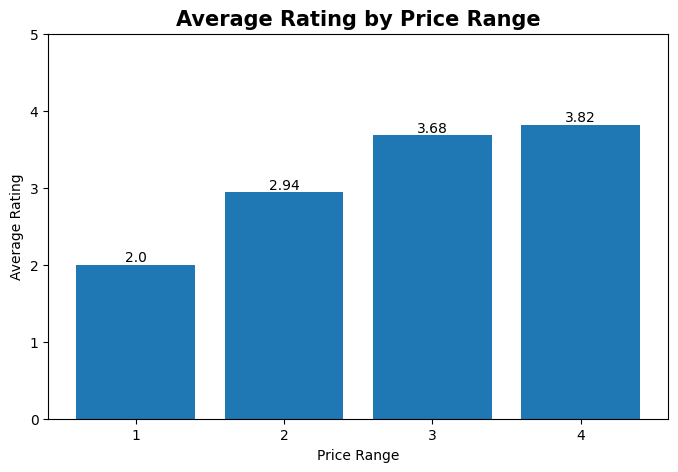

In [ ]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    price_rating.index.astype(str),
    price_rating.values
)

plt.title(
    "Average Rating by Price Range",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Price Range")
plt.ylabel("Average Rating")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        round(bar.get_height(),2),
        ha="center",
        va="bottom"
    )

plt.ylim(0,5)

plt.show()

### Business Insights

- Higher-priced restaurants generally receive higher customer ratings.
- Price Range 4 restaurants have the highest average rating (3.82).
- Budget restaurants (Price Range 1) have the lowest average rating (2.00).
- There is a positive relationship between restaurant pricing and customer satisfaction.
- Premium restaurants tend to provide better dining experiences, resulting in higher ratings.

### Summary

Restaurant ratings increase consistently with price range. Customers appear more satisfied with premium restaurants, suggesting that higher spending is often associated with better service quality, food quality, and overall dining experience.

### Objective

- Compare average customer votes between restaurants with and without online delivery.
- Analyze whether online delivery impacts restaurant popularity.
- Identify customer engagement patterns.


In [ ]:
delivery_votes = (
    df.groupby("Has Online delivery")["Votes"]
    .mean()
)

delivery_votes

Has Online delivery
No     138.131127
Yes    211.307222
Name: Votes, dtype: float64

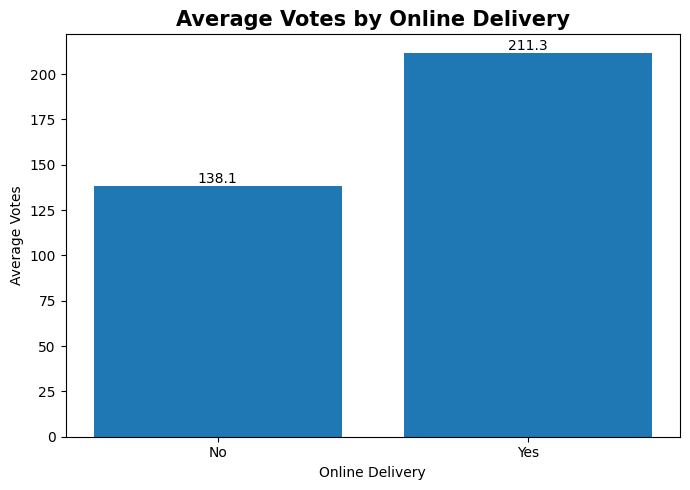

In [ ]:
plt.figure(figsize=(7,5))

bars = plt.bar(
    delivery_votes.index,
    delivery_votes.values
)

plt.title(
    "Average Votes by Online Delivery",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Online Delivery")
plt.ylabel("Average Votes")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        round(bar.get_height(),1),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Business Insights

- Restaurants offering online delivery receive significantly more customer votes.
- Online delivery restaurants average 211 votes, compared to 138 votes for restaurants without delivery.
- Online delivery increases customer reach and engagement.
- Restaurants with delivery services tend to be more popular among customers.
- Adopting online delivery can improve visibility and customer interaction.

### Summary

Restaurants that provide online delivery receive substantially higher customer engagement. This suggests that online delivery is an important factor in increasing restaurant popularity and attracting more customer interactions.

### Objective

- Analyze how online delivery varies across price ranges.
- Analyze how table booking varies across price ranges.
- Identify customer service patterns among budget and premium restaurants.

In [ ]:
online_delivery_price = pd.crosstab(
    df["Price range"],
    df["Has Online delivery"]
)

online_delivery_price

Has Online delivery,No,Yes
Price range,,
1,3743,701
2,1827,1286
3,997,411
4,533,53


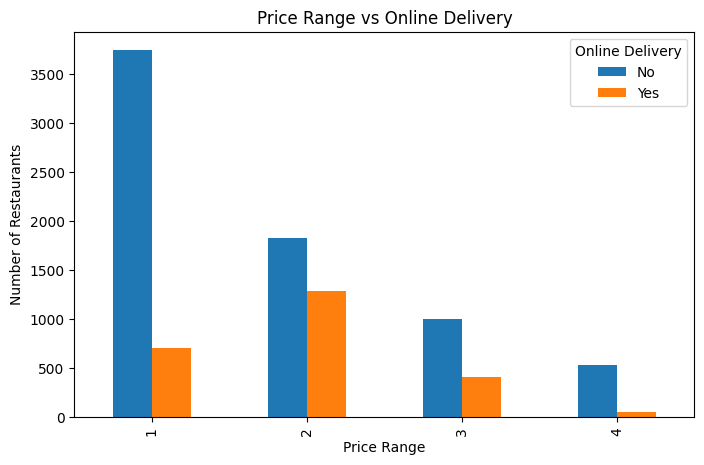

In [ ]:
online_delivery_price.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Price Range vs Online Delivery")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")
plt.legend(title="Online Delivery")
plt.show()

In [ ]:
table_booking_price = pd.crosstab(
    df["Price range"],
    df["Has Table booking"]
)

table_booking_price

Has Table booking,No,Yes
Price range,,
1,4443,1
2,2874,239
3,764,644
4,312,274


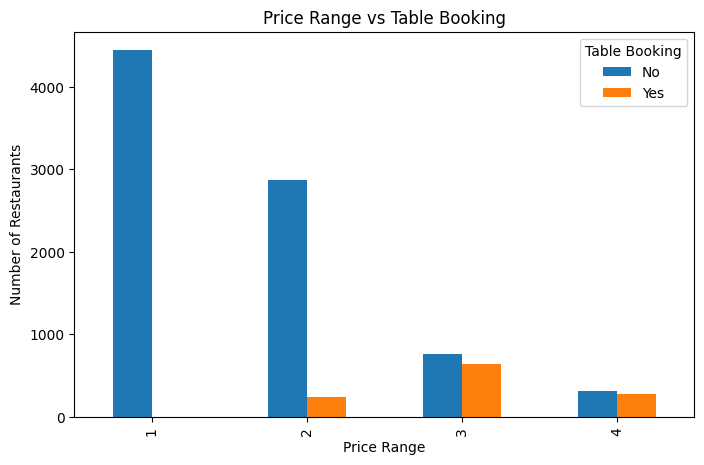

In [ ]:
table_booking_price.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Price Range vs Table Booking")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")
plt.legend(title="Table Booking")
plt.show()

• Online delivery is most popular among mid-range restaurants (Price Range 2).

• Premium restaurants (Price Range 4) rarely provide online delivery services.

• Table booking availability increases significantly with restaurant price range.

• Budget restaurants focus on quick-service operations, while premium restaurants emphasize dine-in experiences and reservations.

• Customer service offerings vary by pricing strategy, with higher-priced restaurants providing more reservation facilities.

# Key Business Insights

1. North Indian cuisine is the most popular cuisine, followed by Chinese and Fast Food.

2. New Delhi contains the highest concentration of restaurants in the dataset.

3. Most restaurants belong to lower and medium price ranges, indicating strong demand for affordable dining options.

4. Only about 25% of restaurants offer online delivery, while 75% do not.

5. Restaurants providing online delivery receive higher average ratings and significantly more customer votes.

6. Premium restaurants generally achieve higher customer ratings than budget restaurants.

7. Customer votes and ratings show a positive correlation, indicating that highly rated restaurants tend to be more popular.

8. India dominates the dataset, containing the majority of listed restaurants.

9. Several restaurant chains operate across multiple locations, with Cafe Coffee Day and Domino's Pizza having the largest presence.

10. Specialty cuisines and international cuisines often achieve the highest customer ratings.

# Conclusion

This project analyzed restaurant data using Python, Pandas, Matplotlib, and Exploratory Data Analysis techniques.

The analysis revealed important trends related to cuisines, cities, ratings, pricing, online delivery, customer votes, and restaurant chains. Results indicate that customer satisfaction is influenced by pricing, cuisine type, and online delivery availability.

These insights can help restaurant owners and business analysts make data-driven decisions regarding expansion, pricing strategies, menu offerings, and delivery services.

# Future Improvements

- Build an interactive dashboard using Power BI or Tableau.
- Create predictive models to estimate restaurant ratings.
- Perform sentiment analysis using customer reviews.
- Develop recommendation systems for restaurants.
- Analyze geographic patterns using interactive maps.
- Build a Streamlit web application for real-time exploration.